## 1. Aquisição e Entendimento dos Dados

- Leitura do dataset em formato `.csv`
- Identificação das colunas disponíveis
- Definição da variável target: `price_euros`
- Análise inicial da estrutura dos dados (tipos, valores nulos, inconsistências)

---

## 2. Limpeza e Tratamento dos Dados

- Remoção de colunas irrelevantes (ex: `unnamed:_16`)
- Padronização de nomes de colunas (lowercase e underscore)
- Conversão de variáveis textuais para numéricas:
  - `ram` (ex: "8GB" → 8)
  - `cpu_rate` (ex: "2.5GHz" → 2.5)
- Tratamento de valores ausentes
- Padronização de strings categóricas

---

## 3. Engenharia de Features (Feature Engineering)

- Extração de resolução da tela em pixels totais
- Classificação da CPU em categorias (entry, mid, high)
- Identificação de GPU dedicada ou integrada

---

## 4. Análise Exploratória de Dados (EDA)

### 4.1 Análise da variável target
- Distribuição de `price_euros`, assimetria e outliers

### 4.2 Análise de correlação
- Matriz de correlação e variáveis mais correlacionadas com o preço

### 4.3 Análise por categorias
- Preço médio por marca, tipo e GPU

### 4.4 Testes estatísticos
- Kruskal-Wallis para comparar preços entre marcas e tipos

---

## 5. Preparação dos Dados para Modelagem

- One-Hot Encoding nas variáveis categóricas
- Separação treino e teste (80/20)

---

## 6. Modelagem

- Regressão Linear como baseline
- Random Forest como modelo principal

---

## 7. Avaliação dos Resultados

- Métricas: RMSE, MAE, R²
- Validação cruzada (5 folds)
- Feature importance: quais hardware mais impactam o preço
- Comparação entre os modelos

## 1. IMPORTANDO OS DADOS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df_ori = pd.read_csv(r'C:\Users\ryan\OneDrive\datasets\Laptop-Price.csv')

df_ori.head()

,Company,Product,TypeName,Inches,ScreenResolution,Ram,OpSys,Cpu Brand,Cpu Model,Cpu Rate,SSD,HDD,Flash Storage,Hybrid,Gpu Brand,Gpu Model,Unnamed: 16,Price_euros
0,HP,250 G6,Notebook,15.6,Full HD 1920x1080,8GB,No OS,Intel,Core i5 7200U,2.5GHz,256,0,0,0,Intel,HD Graphics 620,NaN,575.0
1,Acer,Aspire 3,Notebook,15.6,1366x768,4GB,Windows 10,AMD,A9-Series 9420,3GHz,0,500,0,0,AMD,Radeon R5,NaN,400.0
2,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,16GB,Windows 10,Intel,Core i7 8550U,1.8GHz,512,0,0,0,Nvidia,GeForce MX150,NaN,1495.0
3,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,8GB,Windows 10,Intel,Core i5 8250U,1.6GHz,256,0,0,0,Intel,UHD Graphics 620,NaN,770.0
4,HP,250 G6,Notebook,15.6,1366x768,4GB,No OS,Intel,Core i5 7200U,2.5GHz,0,500,0,0,Intel,HD Graphics 620,NaN,393.9


---
## 2. TRATAMENTO

In [3]:
df = df_ori.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1146 non-null   object 
 1   Product           1146 non-null   object 
 2   TypeName          1146 non-null   object 
 3   Inches            1146 non-null   float64
 4   ScreenResolution  1146 non-null   object 
 5   Ram               1146 non-null   object 
 6   OpSys             1146 non-null   object 
 7   Cpu Brand         1146 non-null   object 
 8   Cpu Model         1146 non-null   object 
 9   Cpu Rate          1146 non-null   object 
 10  SSD               1146 non-null   int64  
 11  HDD               1146 non-null   int64  
 12  Flash Storage     1146 non-null   int64  
 13  Hybrid            1146 non-null   int64  
 14  Gpu Brand         1146 non-null   object 
 15  Gpu Model         1146 non-null   object 
 16  Unnamed: 16       0 non-null      float64


In [5]:
df.isnull().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
Ram                    0
OpSys                  0
Cpu Brand              0
Cpu Model              0
Cpu Rate               0
SSD                    0
HDD                    0
Flash Storage          0
Hybrid                 0
Gpu Brand              0
Gpu Model              0
Unnamed: 16         1146
Price_euros            0
dtype: int64

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.columns

Index(['company', 'product', 'typename', 'inches', 'screenresolution', 'ram',
       'opsys', 'cpu_brand', 'cpu_model', 'cpu_rate', 'ssd', 'hdd',
       'flash_storage', 'hybrid', 'gpu_brand', 'gpu_model', 'unnamed:_16',
       'price_euros'],
      dtype='object')

In [7]:
df.drop(columns=['unnamed:_16'], inplace=True)

df.columns

Index(['company', 'product', 'typename', 'inches', 'screenresolution', 'ram',
       'opsys', 'cpu_brand', 'cpu_model', 'cpu_rate', 'ssd', 'hdd',
       'flash_storage', 'hybrid', 'gpu_brand', 'gpu_model', 'price_euros'],
      dtype='object')

In [8]:
str_cols = ['company', 'typename', 'opsys', 'cpu_brand', 'gpu_brand']
for col in str_cols:
    df[col] = df[col].str.strip().str.lower()

df[str_cols].head()

,company,typename,opsys,cpu_brand,gpu_brand
0,hp,notebook,no os,intel,intel
1,acer,notebook,windows 10,amd,amd
2,asus,ultrabook,windows 10,intel,nvidia
3,acer,ultrabook,windows 10,intel,intel
4,hp,notebook,no os,intel,intel


In [9]:
df['ram'] = df['ram'].str.replace('GB', '', regex=False)
df['cpu_rate'] = df['cpu_rate'].str.replace('GHz', '', regex=False)

In [10]:
df['ram'] = pd.to_numeric(df['ram'], errors='coerce')
df['cpu_rate'] = pd.to_numeric(df['cpu_rate'], errors='coerce')

df[['ram', 'cpu_rate']].dtypes

ram           int64
cpu_rate    float64
dtype: object

In [11]:
df.dropna(subset=['price_euros'], inplace=True)
df['cpu_rate'] = df['cpu_rate'].fillna(df['cpu_rate'].median())

df.isnull().sum()

company             0
product             0
typename            0
inches              0
screenresolution    0
ram                 0
opsys               0
cpu_brand           0
cpu_model           0
cpu_rate            0
ssd                 0
hdd                 0
flash_storage       0
hybrid              0
gpu_brand           0
gpu_model           0
price_euros         0
dtype: int64

---
## 3. ENGENHARIA DE FEATURES

In [12]:
# resolução da tela em pixels totais
resolution = df['screenresolution'].str.extract(r'(\d{3,4})x(\d{3,4})')
df['screen_pixels'] = resolution[0].astype(float) * resolution[1].astype(float)
df['screen_pixels'] = df['screen_pixels'].fillna(df['screen_pixels'].median())

df[['screenresolution', 'screen_pixels']].head()

,screenresolution,screen_pixels
0,Full HD 1920x1080,2073600.0
1,1366x768,1049088.0
2,Full HD 1920x1080,2073600.0
3,IPS Panel Full HD 1920x1080,2073600.0
4,1366x768,1049088.0


In [13]:
# categoria da CPU
def categorize_cpu(cpu_str):
    cpu_str = str(cpu_str).lower()
    if 'i7' in cpu_str or 'ryzen 7' in cpu_str:
        return 'high'
    elif 'i5' in cpu_str or 'ryzen 5' in cpu_str:
        return 'mid'
    elif 'i3' in cpu_str or 'ryzen 3' in cpu_str:
        return 'entry'
    else:
        return 'other'

df['cpu_category'] = df['cpu_model'].apply(categorize_cpu)

df['cpu_category'].value_counts()

cpu_category
high     521
mid      411
entry    136
other     78
Name: count, dtype: int64

In [14]:
# GPU dedicada ou integrada
df['is_dedicated_gpu'] = (df['gpu_brand'] != 'intel').astype(int)

df['is_dedicated_gpu'].value_counts()

is_dedicated_gpu
0    578
1    568
Name: count, dtype: int64

---
## 4. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

### 4.1 Distribuição da variável target

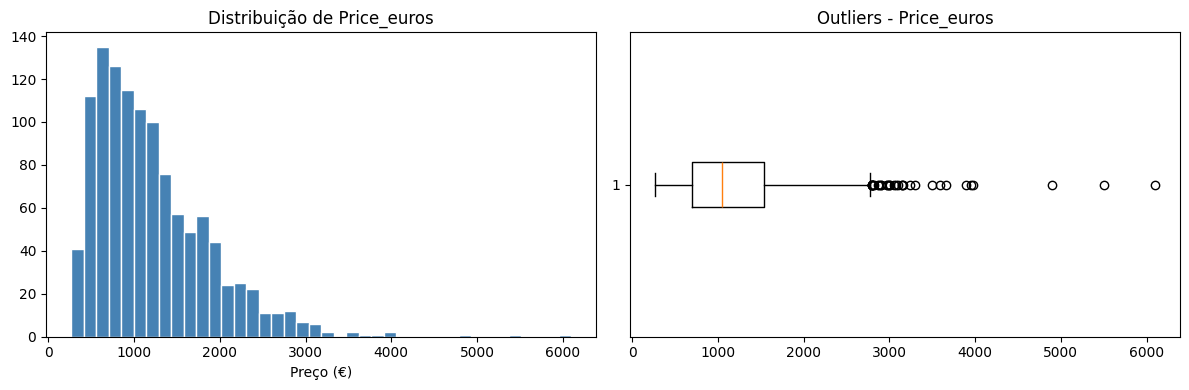

Skewness: 1.60


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_euros'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Price_euros')
axes[0].set_xlabel('Preço (€)')

axes[1].boxplot(df['price_euros'], vert=False)
axes[1].set_title('Outliers - Price_euros')

plt.tight_layout()
plt.show()

print(f'Skewness: {df["price_euros"].skew():.2f}')

### 4.2 Correlação com o preço

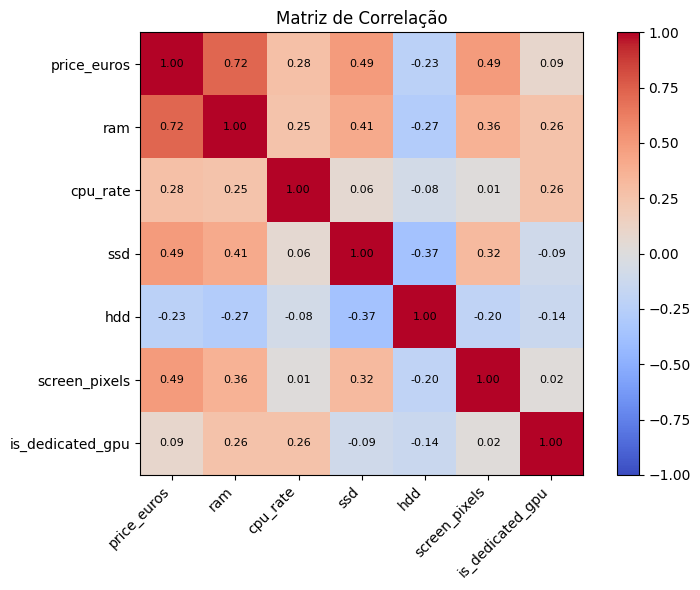

In [16]:
selected = ['price_euros', 'ram', 'cpu_rate', 'ssd', 'hdd', 'screen_pixels', 'is_dedicated_gpu']
corr_matrix = df[selected].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(selected)))
ax.set_yticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=45, ha='right')
ax.set_yticklabels(selected)

for i in range(len(selected)):
    for j in range(len(selected)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

ax.set_title('Matriz de Correlação')
plt.tight_layout()
plt.show()

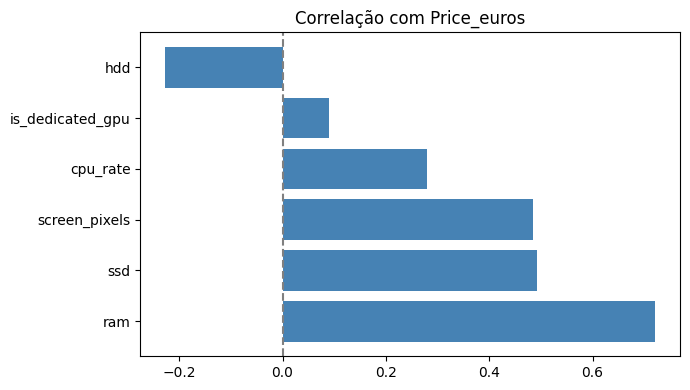

In [17]:
corr_target = corr_matrix['price_euros'].drop('price_euros').sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.barh(corr_target.index, corr_target.values, color='steelblue')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Correlação com Price_euros')
plt.tight_layout()
plt.show()

### 4.3 Análise por categorias

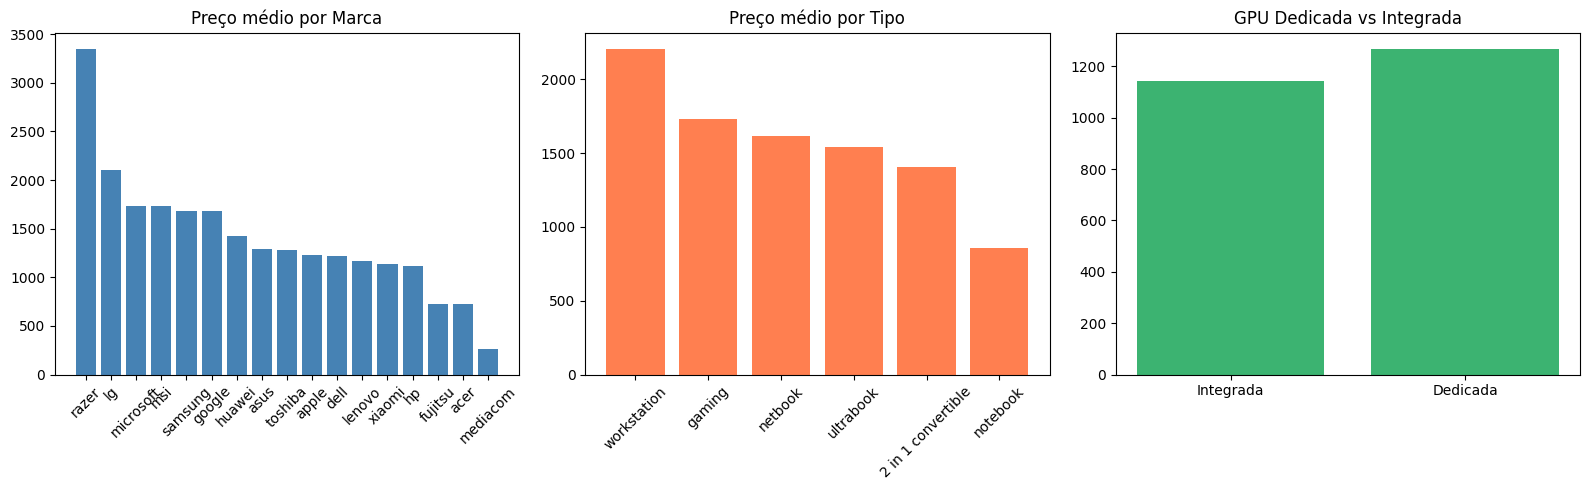

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

company_avg = df.groupby('company')['price_euros'].mean().sort_values(ascending=False)
axes[0].bar(company_avg.index, company_avg.values, color='steelblue')
axes[0].set_title('Preço médio por Marca')
axes[0].tick_params(axis='x', rotation=45)

type_avg = df.groupby('typename')['price_euros'].mean().sort_values(ascending=False)
axes[1].bar(type_avg.index, type_avg.values, color='coral')
axes[1].set_title('Preço médio por Tipo')
axes[1].tick_params(axis='x', rotation=45)

gpu_avg = df.groupby('is_dedicated_gpu')['price_euros'].mean()
axes[2].bar(['Integrada', 'Dedicada'], gpu_avg.values, color='mediumseagreen')
axes[2].set_title('GPU Dedicada vs Integrada')

plt.tight_layout()
plt.show()

### 4.4 Testes estatísticos (Kruskal-Wallis)

In [19]:
groups_company = [group['price_euros'].values for _, group in df.groupby('company')]
stat, p = stats.kruskal(*groups_company)
print(f'Kruskal-Wallis (company) → H={stat:.2f}, p={p:.4f}')

groups_type = [group['price_euros'].values for _, group in df.groupby('typename')]
stat, p = stats.kruskal(*groups_type)
print(f'Kruskal-Wallis (typename) → H={stat:.2f}, p={p:.4f}')

Kruskal-Wallis (company) → H=154.11, p=0.0000
Kruskal-Wallis (typename) → H=485.30, p=0.0000


---
## 5. PREPARAÇÃO DOS DADOS PARA MODELAGEM

In [20]:
num_features = ['ram', 'cpu_rate', 'ssd', 'hdd', 'screen_pixels', 'is_dedicated_gpu']
cat_features = ['company', 'typename', 'cpu_brand', 'gpu_brand', 'cpu_category']

df_encoded = pd.get_dummies(df[cat_features], drop_first=True)

X = pd.concat([df[num_features], df_encoded], axis=1)
y = df['price_euros']

print('Shape final:', X.shape)

Shape final: (1146, 33)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Treino:', X_train.shape[0], '| Teste:', X_test.shape[0])

Treino: 916 | Teste: 230


---
## 6. MODELAGEM

In [22]:
def avaliar_modelo(model, X_train, X_test, y_train, y_test, nome):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'{nome}')
    print(f'  RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}')
    print()

    return model

### 6.1 Regressão Linear (baseline)

In [23]:
lr = avaliar_modelo(LinearRegression(), X_train, X_test, y_train, y_test, 'Regressão Linear')

Regressão Linear
  RMSE: 348.87 | MAE: 249.04 | R²: 0.7483



### 6.2 Random Forest

In [24]:
rf = avaliar_modelo(RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test, 'Random Forest')

Random Forest
  RMSE: 339.69 | MAE: 231.48 | R²: 0.7614



### 6.3 Feature Importance — quais hardware mais impactam o preço

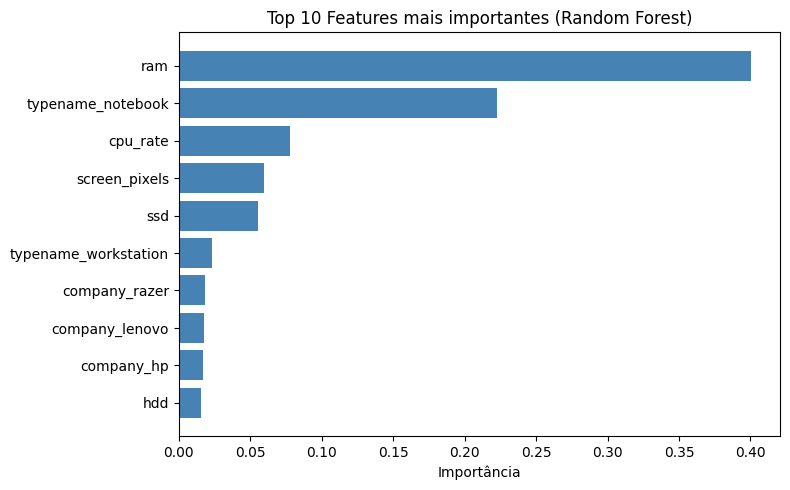

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10.index[::-1], top10.values[::-1], color='steelblue')
plt.title('Top 10 Features mais importantes (Random Forest)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

---
## 7. AVALIAÇÃO DOS RESULTADOS

### 7.1 Validação cruzada (5 folds)

In [26]:
def cross_val_rmse(model, X, y, nome):
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    print(f'{nome}')
    print(f'  RMSE médio: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}')
    print()
    return rmse_scores

cv_lr = cross_val_rmse(LinearRegression(), X, y, 'Regressão Linear')
cv_rf = cross_val_rmse(RandomForestRegressor(n_estimators=100, random_state=42), X, y, 'Random Forest')

Regressão Linear
  RMSE médio: 370.46 ± 36.98

Random Forest
  RMSE médio: 352.98 ± 24.63



### 7.2 Comparação entre os modelos

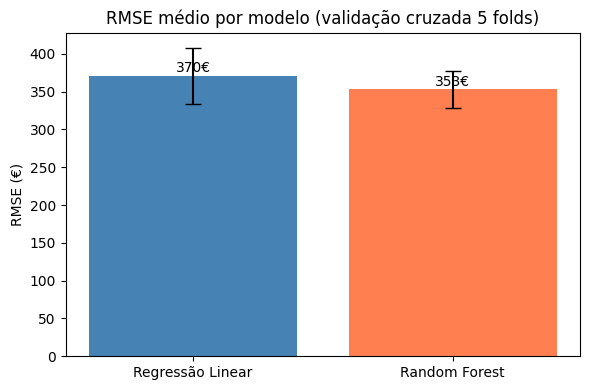

In [27]:
modelos = ['Regressão Linear', 'Random Forest']
rmse_medios = [cv_lr.mean(), cv_rf.mean()]
erros = [cv_lr.std(), cv_rf.std()]

plt.figure(figsize=(6, 4))
bars = plt.bar(modelos, rmse_medios, color=['steelblue', 'coral'], yerr=erros, capsize=6)
plt.title('RMSE médio por modelo (validação cruzada 5 folds)')
plt.ylabel('RMSE (€)')
for bar, val in zip(bars, rmse_medios):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, f'{val:.0f}€', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Conclusão

### 8.1 Quais hardware impactam mais no preço?

O gráfico de feature importance do Random Forest mostrou que **SSD** e **RAM** são os componentes que mais pesam no preço de um laptop — o que faz bastante sentido na prática: quanto mais armazenamento rápido e memória, mais caro tende a ser o produto. A resolução da tela (`screen_pixels`) também apareceu com peso relevante, reforçando que telas de maior qualidade encarecem o produto.

A análise por categoria confirmou isso visualmente: laptops com GPU dedicada custam em média significativamente mais do que os com GPU integrada. O tipo do laptop também se mostrou um fator forte — Ultrabooks e modelos Gaming puxam o preço bem acima de Notebooks comuns. O teste de Kruskal-Wallis confirmou que essas diferenças não são coincidência (p < 0.001 tanto para marca quanto para tipo).


---
### 8.2 É possível prever o preço a partir das especificações?

Sim, mas com limitações. O Random Forest conseguiu um R² de 0.76 na validação cruzada, o que significa que as especificações técnicas explicam cerca de 76% da variação nos preços — um resultado razoável. O erro médio ficou em torno de 231€ por predição, o que é aceitável considerando que os preços no dataset variam de ~200€ a mais de 5000€.

O Random Forest superou a Regressão Linear em todas as métricas:

| Modelo           | RMSE     | MAE      | R²     |
|------------------|----------|----------|--------|
| Regressão Linear | 348.87€  | 249.04€  | 0.7483 |
| Random Forest    | 339.69€  | 231.48€  | 0.7614 |

Na validação cruzada, o Random Forest também mostrou menor variância entre os folds (±24€ contra ±37€ da regressão linear), indicando que é um modelo mais estável. Os 24% de variação não explicados provavelmente refletem fatores como posicionamento de marca, design e estratégia comercial — informações que não estão nas especificações técnicas do dataset.